# Clustering de estudios usando CRISP-DM

Esta libreta documenta una solucion de **clustering no
supervisado** para agrupar estudios con comportamiento operativo
similar.


## 1. Comprension del negocio

- Solucion: clustering con `KMeans`.
- Objetivo: encontrar grupos de estudios con comportamiento
  operativo similar sin usar etiquetas previas.
- Unidad de analisis: estudio individual activo.


## 2. Comprension de los datos

Primero se carga el dataset producido por ETL y se revisa su
estructura general.


In [1]:
import os
import json
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

os.environ["LOKY_MAX_CPU_COUNT"] = "1"

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

BACKEND = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "package.json").exists() and (path / "src").exists()
)
RANDOM_STATE = 42


In [2]:
df = pd.read_csv(BACKEND / "05_Datasets" / "clustering_estudios.csv")
print(df.head().to_string(index=False))


 study_id    code                           name  price  delivery_hours  parameter_count  request_count  synthetic_request_count sample_type    analysis_method requires_special_processing  is_synthetic
        1 GLU-001                        GLUCOSA    110            1.00              NaN              5                        1         NaN                NaN                         NaN         False
        2    BH01             BIOMETRIA HEMATICA    180            0.50              NaN              3                        1         NaN       AUTOMATIZADO                         NaN         False
        3    QS06  QUIMICA SANGUINEA 6 ELEMENTOS    220            0.75              NaN              0                        0         NaN ESPECTROFOTOMETRIA                         NaN         False
        4    QS12 QUIMICA SANGUINEA 12 ELEMENTOS    350            1.00              NaN              4                        2         NaN ESPECTROFOTOMETRIA                         NaN     

In [3]:
print(df.shape)


(2000, 12)


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   study_id                     2000 non-null   int64  
 1   code                         2000 non-null   str    
 2   name                         2000 non-null   str    
 3   price                        2000 non-null   int64  
 4   delivery_hours               2000 non-null   float64
 5   parameter_count              1953 non-null   float64
 6   request_count                2000 non-null   int64  
 7   synthetic_request_count      2000 non-null   int64  
 8   sample_type                  1958 non-null   str    
 9   analysis_method              1999 non-null   str    
 10  requires_special_processing  1958 non-null   object 
 11  is_synthetic                 2000 non-null   bool   
dtypes: bool(1), float64(2), int64(4), object(1), str(4)
memory usage: 174.0+ KB


In [5]:
print(df[["price", "delivery_hours", "parameter_count", "request_count"]].describe().round(2).to_string())


         price  delivery_hours  parameter_count  request_count
count  2000.00         2000.00          1953.00        2000.00
mean    600.32            3.59            15.51           1.19
std     230.39            3.55             8.70           1.12
min      80.00            0.25             1.00           0.00
25%     420.00            1.75             8.00           0.00
50%     600.00            2.50            15.00           1.00
75%     770.00            3.50            23.00           2.00
max    1260.00           48.00            32.00           5.00


In [6]:
print(
    df[
        [
            "price",
            "delivery_hours",
            "parameter_count",
            "request_count",
            "sample_type",
            "analysis_method",
        ]
    ].isnull().sum().to_string()
)


price               0
delivery_hours      0
parameter_count    47
request_count       0
sample_type        42
analysis_method     1


### Control de calidad inicial

Las salidas anteriores documentan:

- muestra inicial
- dimensiones
- tipos de dato
- estadisticos descriptivos
- valores faltantes

En la preparacion tambien se imputan nulos antes del escalado.


### Descripcion de las variables

Para esta propuesta se usan variables numericas sencillas:

- `price`
- `delivery_hours`
- `parameter_count`
- `request_count`


## 3. Preparacion de los datos

Se seleccionan las variables del clustering, se imputan nulos con la
mediana y despues se escalan los datos.


In [7]:
features = ["price", "delivery_hours", "parameter_count", "request_count"]

X = df[features].copy()
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Variables usadas:", features)
print("Filas utiles:", len(X))


Variables usadas: ['price', 'delivery_hours', 'parameter_count', 'request_count']
Filas utiles: 2000


## 4. Modelado: seleccion de la cantidad de clusters

Se prueban varios valores de `k` y se revisan tres evidencias:

- inercia
- silhouette
- Davies-Bouldin

Para reproducibilidad se usa `RANDOM_STATE = 42`.


In [8]:
resultados = []

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_scaled)
    resultados.append(
        {
            "k": k,
            "inertia": round(float(model.inertia_), 4),
            "silhouette": round(float(silhouette_score(X_scaled, labels)), 4),
            "davies_bouldin": round(float(davies_bouldin_score(X_scaled, labels)), 4),
        }
    )

resultados = pd.DataFrame(resultados)
print(resultados.to_string(index=False))


 k   inertia  silhouette  davies_bouldin
 2 5170.9578      0.3387          1.1965
 3 4135.4452      0.3578          1.1498
 4 3346.8123      0.3430          1.0588
 5 2769.8232      0.3238          1.0944
 6 2436.8840      0.3073          1.0203


### Grafica de inercia por numero de clusters

Esta grafica complementa la tabla anterior y ayuda a visualizar el
comportamiento de la inercia conforme cambia `k`.


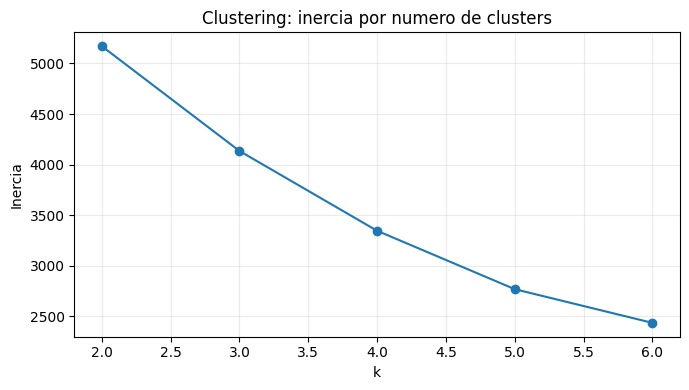

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(resultados["k"], resultados["inertia"], marker="o", color="#1f77b4")
ax.set_title("Clustering: inercia por numero de clusters")
ax.set_xlabel("k")
ax.set_ylabel("Inercia")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Graficas de silhouette y Davies-Bouldin

Estas dos metricas complementan al metodo del codo. `Silhouette`
se interpreta mejor cuando es mayor, mientras que
`Davies-Bouldin` se interpreta mejor cuando es menor.


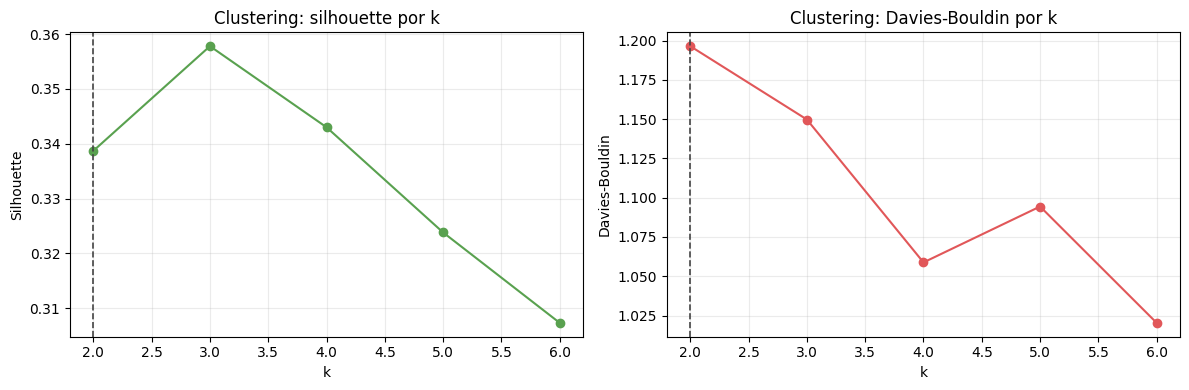

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(resultados["k"], resultados["silhouette"], marker="o", color="#59a14f")
axes[0].axvline(2, linestyle="--", color="#444444", linewidth=1.2)
axes[0].set_title("Clustering: silhouette por k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette")
axes[0].grid(alpha=0.25)

axes[1].plot(resultados["k"], resultados["davies_bouldin"], marker="o", color="#e15759")
axes[1].axvline(2, linestyle="--", color="#444444", linewidth=1.2)
axes[1].set_title("Clustering: Davies-Bouldin por k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Davies-Bouldin")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [11]:
k_recomendado_metricas = int(
    resultados.sort_values(
        ["silhouette", "davies_bouldin"],
        ascending=[False, True],
    ).iloc[0]["k"]
)
k_elegido = 2

print("k sugerido por silhouette + Davies-Bouldin:", k_recomendado_metricas)
print("k adoptado para la propuesta:", k_elegido)


k sugerido por silhouette + Davies-Bouldin: 3
k adoptado para la propuesta: 2


### Interpretacion del agrupamiento

El metodo del codo muestra un cambio importante alrededor de `k=3`,
y las metricas internas tambien dan una ligera ventaja tecnica a
`k=3`. Aun asi, en esta propuesta se adopta `k=2` como decision
final porque:

- la diferencia de `silhouette` entre `k=2` y `k=3` es pequena
- `k=2` permite una segmentacion mas simple de explicar en clase
- se evita fragmentar demasiado el catalogo de estudios

En otras palabras: `k=3` es la mejor recomendacion automatica, pero
`k=2` se usa por interpretabilidad operativa.


## 5. Entrenamiento final y asignacion de clusters

Se entrena el modelo final con el valor de `k` seleccionado y se
calcula el cluster de cada estudio.


In [12]:
final_model = KMeans(n_clusters=k_elegido, random_state=RANDOM_STATE, n_init=10)
labels = final_model.fit_predict(X_scaled)
distances = final_model.transform(X_scaled).min(axis=1)

thresholds = {}
for cluster in range(k_elegido):
    cluster_distances = np.sort(distances[labels == cluster])
    q1 = np.quantile(cluster_distances, 0.25)
    q3 = np.quantile(cluster_distances, 0.75)
    iqr = q3 - q1
    thresholds[cluster] = q3 + 1.5 * iqr if iqr > 0 else q3

asignaciones = df[["study_id", "code", "name"]].copy()
asignaciones["cluster"] = labels + 1
asignaciones["distance_to_centroid"] = np.round(distances, 4)
asignaciones["is_outlier"] = [
    bool(distances[i] > thresholds[labels[i]])
    for i in range(len(labels))
]

print(asignaciones.head(8).to_string(index=False))


 study_id    code                           name  cluster  distance_to_centroid  is_outlier
        1 GLU-001                        GLUCOSA        1                3.7752        True
        2    BH01             BIOMETRIA HEMATICA        1                2.1389       False
        3    QS06  QUIMICA SANGUINEA 6 ELEMENTOS        1                1.6037       False
        4    QS12 QUIMICA SANGUINEA 12 ELEMENTOS        1                2.6905        True
        5   GLU01                        GLUCOSA        1                3.8497        True
        6   HBA1C  Hemoglobina glucosilada HbA1c        1                1.4330       False
        7   COL01               COLESTEROL TOTAL        1                1.7011       False
        8   TRI01                  TRIGLICERIDOS        1                3.0526        True


### Grafica de distribucion de clusters

La siguiente grafica muestra una vista simple de los estudios en el
plano `price` contra `delivery_hours`, coloreados por cluster.


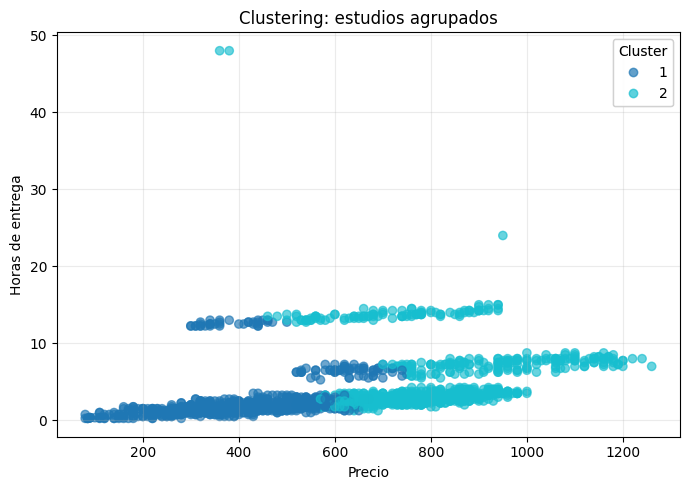

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    df["price"],
    df["delivery_hours"],
    c=asignaciones["cluster"],
    cmap="tab10",
    alpha=0.65,
)
ax.set_title("Clustering: estudios agrupados")
ax.set_xlabel("Precio")
ax.set_ylabel("Horas de entrega")
ax.grid(alpha=0.25)
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.tight_layout()
plt.show()


## 6. Exportacion del modelo

El modelo entrenado se guarda en
`07_Modelos/clustering_estudios_model.pkl`.
Ese mismo nombre es el que espera el flujo Python del sistema web
en `ml-artifacts/scripts/clustering_model.py`.


In [14]:
model_relative = Path("07_Modelos") / "clustering_estudios_model.pkl"
assignments_relative = Path("05_Datasets") / "clustering_estudios_asignaciones.csv"
model_path = BACKEND / model_relative
assignments_path = BACKEND / assignments_relative

bundle = {
    "model": final_model,
    "scaler": scaler,
    "features": features,
    "outlier_thresholds": thresholds,
}

with model_path.open("wb") as file:
    pickle.dump(bundle, file)

asignaciones.to_csv(assignments_path, index=False)

print("Modelo exportado en:", model_relative.as_posix())
print("Asignaciones guardadas en:", assignments_relative.as_posix())


Modelo exportado en: 07_Modelos/clustering_estudios_model.pkl
Asignaciones guardadas en: 05_Datasets/clustering_estudios_asignaciones.csv


## 7. Ejemplo de asignacion

Como salida final, cada estudio queda asociado a un cluster.


In [15]:
print(
    json.dumps(
        asignaciones.iloc[0][["study_id", "cluster", "distance_to_centroid", "is_outlier"]].to_dict(),
        indent=2,
        ensure_ascii=False,
    )
)


{
  "study_id": 1,
  "cluster": 1,
  "distance_to_centroid": 3.7752,
  "is_outlier": true
}
